In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import scipy.stats as st


from PIL import Image

# Initial Check

## Import dataset

In [6]:
# Adjust path if needed
meta = pd.read_csv('meta_train.csv')

# Display first few rows
print("First 5 rows of metadata:")
display(meta.head())

# Show dataframe info
print("\nMetadata info:")
meta.info()

First 5 rows of metadata:


,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45



Metadata info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10407 entries, 0 to 10406
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  10407 non-null  object
 1   label     10407 non-null  object
 2   variety   10407 non-null  object
 3   age       10407 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 325.3+ KB


## Check stats in "Age"

In [7]:
# Summary statistics for 'age'
age_stats = meta['age'].describe()
missing_ages = meta['age'].isnull().sum()
dup_count = meta['image_id'].duplicated().sum()
age_skewness = meta['age'].skew()

print(f"\nAge summary:\n{age_stats}")
print(f"\nMissing age: {missing_ages}")
print(f"\nDuplicate IDs: {dup_count}")
print(f"\nAge Skewness: {age_skewness:.2f}")


Age summary:
count    10407.000000
mean        64.043624
std          8.958830
min         45.000000
25%         60.000000
50%         67.000000
75%         70.000000
max         82.000000
Name: age, dtype: float64

Missing age: 0

Duplicate IDs: 0

Age Skewness: -0.59


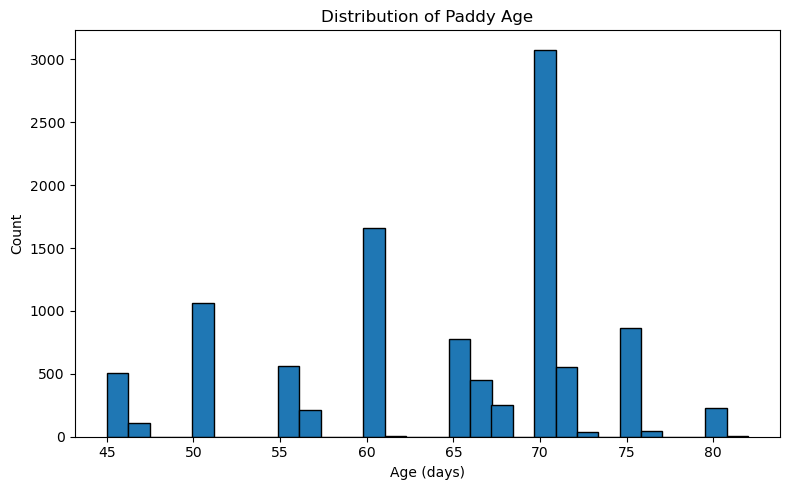

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(meta['age'], bins=30, edgecolor='black')
plt.title('Distribution of Paddy Age')
plt.xlabel('Age (days)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
# Age statistics by variety
variety_stats = (
    meta
    .groupby('variety')['age']
    .agg(count='count', mean='mean', std='std', min='min', max='max')
    .reset_index()
    .sort_values('count', ascending=False)
)

print(variety_stats.to_string(index=False))

       variety  count      mean       std  min  max
         ADT45   6992 64.308924  8.138329   45   82
KarnatakaPonni    988 69.058704 10.239018   50   75
         Ponni    657 60.639269 10.944671   45   80
  AtchayaPonni    461 59.151844  7.416399   45   65
         Zonal    399 67.218045  5.837418   55   70
    AndraPonni    377 59.058355  9.151607   45   65
      Onthanel    351 60.199430 10.012284   50   70
          IR20    114 64.385965  9.026518   50   70
            RR     36 70.000000  0.000000   70   70
         Surya     32 45.000000  0.000000   45   45


Count of Healthy vs. Diseased Samples   health_status  count
0      diseased   8643
1       healthy   1764

Age Statistics by Health Status       label  count       mean       std  min    q1  median    q3  max
0  diseased   8643  64.449150  9.312222   45  57.0    70.0  70.0   80
1   healthy   1764  62.056689  6.625649   50  60.0    60.0  67.0   82


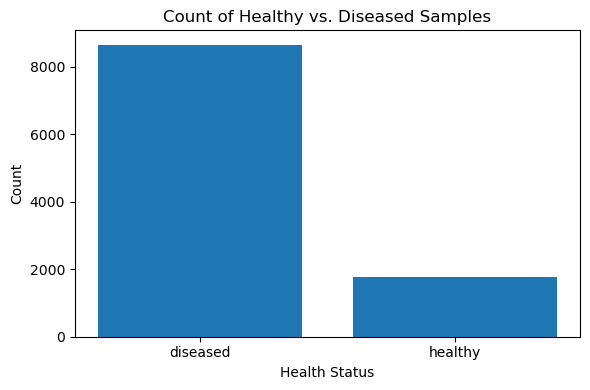

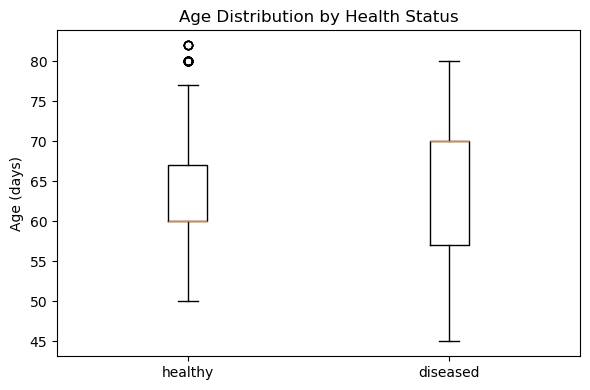

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Derive health status as a separate Series (meta remains unchanged)
health_series = meta['label'].apply(lambda x: 'healthy' if x == 'normal' else 'diseased')

# Count healthy vs. diseased samples
counts = health_series.value_counts().rename_axis('health_status').reset_index(name='count')
print("Count of Healthy vs. Diseased Samples", counts)

print()

# Summary statistics of age by health status, using health_series in groupby
age_stats_by_health = (
    meta
    .groupby(health_series)['age']
    .agg(
        count='count',
        mean='mean',
        std='std',
        min='min',
        q1=lambda x: x.quantile(0.25),
        median='median',
        q3=lambda x: x.quantile(0.75),
        max='max'
    )
    .reset_index()
)
print("Age Statistics by Health Status", age_stats_by_health)

# Bar chart of sample counts
plt.figure(figsize=(6, 4))
plt.bar(counts['health_status'], counts['count'])
plt.title('Count of Healthy vs. Diseased Samples')
plt.xlabel('Health Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Boxplot of age distribution by health status
healthy_ages = meta.loc[health_series == 'healthy', 'age']
diseased_ages = meta.loc[health_series == 'diseased', 'age']

plt.figure(figsize=(6, 4))
plt.boxplot([healthy_ages, diseased_ages], tick_labels=['healthy', 'diseased'])
plt.title('Age Distribution by Health Status')
plt.ylabel('Age (days)')
plt.tight_layout()
plt.show()

## Check for potential typos

In [11]:
print(meta['label'].value_counts())

label
normal                      1764
blast                       1738
hispa                       1594
dead_heart                  1442
tungro                      1088
brown_spot                   965
downy_mildew                 620
bacterial_leaf_blight        479
bacterial_leaf_streak        380
bacterial_panicle_blight     337
Name: count, dtype: int64


In [12]:
print(meta['variety'].value_counts())

variety
ADT45             6992
KarnatakaPonni     988
Ponni              657
AtchayaPonni       461
Zonal              399
AndraPonni         377
Onthanel           351
IR20               114
RR                  36
Surya               32
Name: count, dtype: int64


## Check for image existence

In [13]:
# Point to the train_images folder at the same level as your notebook & CSV
base_dir = "train_images"

# Check each image under its label subfolder
missing = []
for iid, lbl in zip(meta["image_id"], meta["label"]):
    # ensure exactly one ".jpg" extension
    fname = iid if iid.lower().endswith(".jpg") else f"{iid}.jpg"
    path = os.path.join(base_dir, lbl, fname)
    if not os.path.isfile(path):
        missing.append(path)

# Report
print(f"Missing files: {len(missing)}")
if missing:
    print("Examples of missing paths:")
    print("\n".join(missing[:5]))

Missing files: 0


In [14]:
# 2. Point to the folder that contains your 10 class sub‑folders
base_dir = "train_images"

# 3. Get the list of expected class folders (you can also hard‑code the 10 names)
class_folders = sorted([
    d for d in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, d))
])

print("Found class folders:", class_folders)

# 4. Check every row in your CSV for existence under the right class sub‑folder
missing = []
for _, row in meta.iterrows():
    cls = row['label']               # e.g. "bacterial_leaf_blight"
    img_id = row['image_id']         # e.g. "12345"
    filename = img_id if img_id.lower().endswith('.jpg') else f"{img_id}.jpg"
    img_path = os.path.join(base_dir, cls, filename)

    if not os.path.isfile(img_path):
        missing.append(img_path)

# 5. Report
print(f"Total images checked: {len(meta)}")
print(f"Missing files: {len(missing)}")
if missing:
    print("Examples of missing paths:")
    for p in missing[:5]:
        print(" ", p)

Found class folders: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Total images checked: 10407
Missing files: 0


In [15]:
import os
from PIL import Image
import pandas as pd

# 1. Load metadata
meta = pd.read_csv("meta_train.csv")

# 2. Base folder containing the 10 label subfolders
base_dir = "train_images"

# 3. Collect any unreadable or corrupt files
bad = []
for iid, lbl in zip(meta['image_id'], meta['label']):
    # Keep exactly one ".jpg" on the filename
    filename = iid if iid.lower().endswith('.jpg') else f"{iid}.jpg"
    img_path = os.path.join(base_dir, lbl, filename)
    
    try:
        # Try opening and verifying the image
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        bad.append(img_path)

# 4. Report results
print(f"Corrupted images: {len(bad)}")
if bad:
    print("Examples of bad files:")
    for p in bad[:5]:
        print(" ", p)

Corrupted images: 0


## Check image outliers

In [16]:
# 3. Collect all (width, height) tuples
sizes = []
for image_id, label in zip(meta["image_id"], meta["label"]):
    # Ensure exactly one “.jpg”
    fname = image_id if image_id.lower().endswith(".jpg") else f"{image_id}.jpg"
    img_path = os.path.join(base_dir, label, fname)
    
    # Open and record size
    with Image.open(img_path) as img:
        sizes.append(img.size)

# 4. Build DataFrame and count each resolution
df_sizes = pd.DataFrame(sizes, columns=["width", "height"])
resolution_counts = (
    df_sizes
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# 5. Output the table
print(resolution_counts)

   width  height  count
0    480     640  10407


In [17]:
landscapes = []

for image_id, label in zip(meta["image_id"], meta["label"]):
    fname = image_id if image_id.lower().endswith(".jpg") else f"{image_id}.jpg"
    p = os.path.join(base_dir, label, fname)
    with Image.open(p) as img:
        if img.width > img.height:
            landscapes.append(p)
    if len(landscapes) == 4:
        break

print("Landscape outliers:")
for path in landscapes:
    print(" ", path)

Landscape outliers:


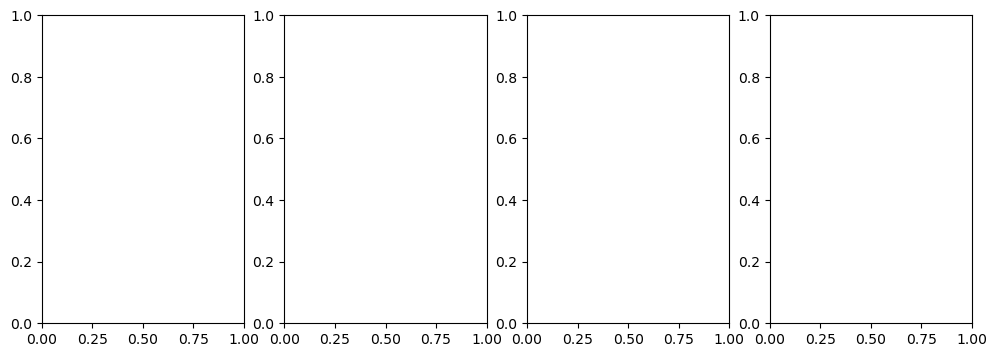

In [18]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4))
for ax, p in zip(axs, landscapes):
    img = Image.open(p)
    ax.imshow(img)
    ax.set_title(os.path.basename(p))
    ax.axis("off")
plt.show()

In [19]:
# Rotate each one 90° CCW and overwrite
for path in landscapes:
    img = Image.open(path)
    img_rot = img.transpose(Image.ROTATE_90)
    img_rot.save(path)
    print(f"Rotated: {path}")

In [21]:
# # Check image's resolution again
# with Image.open(landscapes[0]) as img:
#     print(img.size)

## Age-based sampling

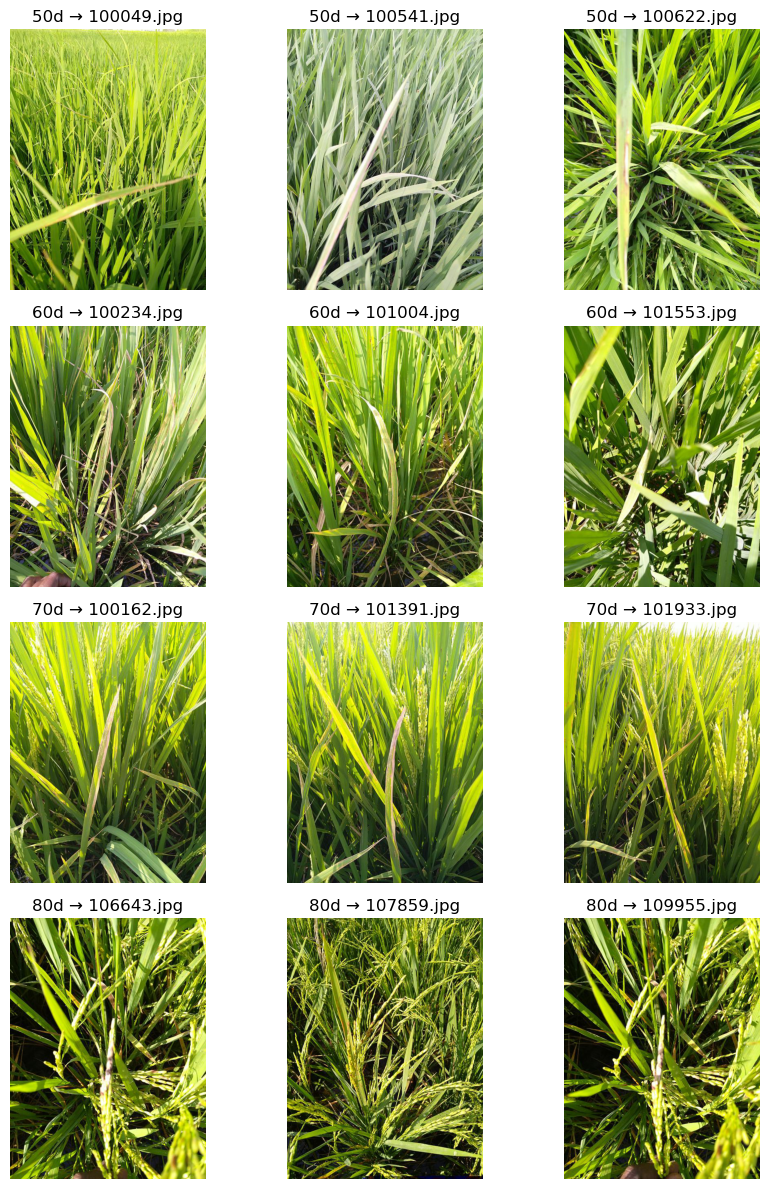

In [22]:
# Choose age milestones (you can tweak these)
milestones = [50, 60, 70, 80]

# For each milestone, find 3 images whose age is closest
samples = []
for age_target in milestones:
    # compute absolute difference
    meta['diff'] = (meta['age'] - age_target).abs()
    # pick 3 smallest diffs
    closest = meta.nsmallest(3, 'diff')
    for _, row in closest.iterrows():
        fname = row['image_id'] if row['image_id'].lower().endswith('.jpg') else f"{row['image_id']}.jpg"
        path = os.path.join(base_dir, row['label'], fname)
        samples.append((age_target, path))

# Plot them in a grid
n_rows = len(milestones)
n_cols = 3
plt.figure(figsize=(n_cols*3, n_rows*3))
for i, (age_target, path) in enumerate(samples):
    img = Image.open(path)
    ax = plt.subplot(n_rows, n_cols, i+1)
    ax.imshow(img)
    ax.set_title(f"{age_target}d → {os.path.basename(path)}")
    ax.axis('off')
plt.tight_layout()
plt.show()

- 50 days: very slender green blades, no sign of panicles, more uniform color.

- 60 days: thicker clumps of blades, slight variation in blade width, still no or just‑emerging panicle tips.

- 70 days: you start to see panicle heads among the leaves, and a bit more yellowing toward the tips.

- 80 days: fully formed panicles with grain, greater textural complexity and warmer (more yellow) tones.



## Split dataset

In [26]:
df = meta.copy()
df['age_bin'] = pd.qcut(df['age'], q=5, labels=False, duplicates='drop')

In [27]:
from sklearn.model_selection import train_test_split

train_val, test = train_test_split(
    df,
    test_size=0.20,
    stratify=df['age_bin'],
    random_state=42
)

In [28]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(skf.split(train_val, train_val['age_bin'])):
    tr, vl = train_val.iloc[tr_idx], train_val.iloc[val_idx]
    print(f"Fold {fold} ages:", tr['age_bin'].value_counts(normalize=True).sort_index().to_dict())
    print(f"       ",       vl['age_bin'].value_counts(normalize=True).sort_index().to_dict())

Fold 0 ages: {0: 0.21585585585585584, 1: 0.2547747747747748, 2: 0.36324324324324325, 3: 0.16612612612612612}
        {0: 0.21585585585585584, 1: 0.2547747747747748, 2: 0.3636036036036036, 3: 0.16576576576576577}
Fold 1 ages: {0: 0.21585585585585584, 1: 0.2547747747747748, 2: 0.36342342342342343, 3: 0.16594594594594594}
        {0: 0.21585585585585584, 1: 0.2547747747747748, 2: 0.36324324324324325, 3: 0.16612612612612612}
Fold 2 ages: {0: 0.21585585585585584, 1: 0.2547747747747748, 2: 0.36342342342342343, 3: 0.16594594594594594}
        {0: 0.21585585585585584, 1: 0.2547747747747748, 2: 0.36324324324324325, 3: 0.16612612612612612}


In [ ]:
# for name, subset in [('Train', train_val), ('Test', test)]:
#     print(f"\n{name} label distribution:\n", subset['label'].value_counts(normalize=True).head())
#     print(f"{name} variety distribution:\n", subset['variety'].value_counts(normalize=True).head())

In [31]:
# %pip install tensorflow
import tensorflow as tf

def preprocess_image(image):
    # 1) Decode & convert to float32 [0,1]
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    # 2) Center‑crop to square
    orig_shape = tf.shape(image)
    height, width = orig_shape[0], orig_shape[1]
    # fraction = min(height, width) / max(height, width)
    central_fraction = tf.cast(tf.minimum(height, width), tf.float32) / tf.cast(tf.maximum(height, width), tf.float32)
    image = tf.image.central_crop(image, central_fraction=central_fraction)

    # 3) Resize to model input (e.g. 224×224)
    image = tf.image.resize(image, [224, 224], method='bilinear')
    
    # 4) (Optionally) apply augmentations here for training only
    #    image = tf.image.random_flip_left_right(image)
    #    image = tf.image.random_brightness(image, 0.1)
    #    …etc…

    # 5) Normalize to zero mean, unit variance (use your dataset stats)
    image = (image - TRAIN_MEAN) / TRAIN_STD

    return image

# Example dataset pipeline
ds = tf.data.TextLineDataset(["train.csv"]) \
    .map(parse_csv_line)  \
    .map(lambda path, age: (preprocess_image(tf.io.read_file(path)), age)) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

^C
Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'tensorflow'

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/376.0 MB 3.4 MB/s eta 0:01:52
   ---------------------------------------- 1.3/376.0 MB 4.0 MB/s eta 0:01:35
   ---------------------------------------- 2.4/376.0 MB 4.1 MB/s eta 0:01:32
   ---------------------------------------- 3.7/376.0 MB 4.8 MB/s eta 0:01:17
    --------------------------------------- 5.0/376.0 MB 5.3 MB/s eta 0:01:10
    --------------------------------------- 6.3/376.0 MB 5.4 MB/s eta 0:01:09
    --------------------------------------- 7.3/376.0 MB 5.3 MB/s eta 0:01:10
    --------------------------------------- 8.7/376.0 MB 5.4 MB/s eta 0:01:09
   - -------------------------------------- 10.0/376.0 MB 5.5 MB/s eta 0:01:07
   - -------------------------------------- 11.0/376.0 MB 5.5 MB/s eta 0:01:07
   - -------------------------------------- 12.3/376.0 MB 5.6 MB/s et

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
